In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
from numpy.ma.core import negative

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [4]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

In [5]:
depth_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.pileup.label.pkl.genomic.pkl")
depth_df = depth_df[["genome_id", "depth", "drach","gene_id"]].reset_index(drop=True)
print(depth_df)

                genome_id  depth  drach            gene_id
0         chr10:+:1000681    519  False           [GTPBP4]
1         chr10:+:1000683    519   True           [GTPBP4]
2         chr10:+:1000685    520  False           [GTPBP4]
3         chr10:+:1000694    519  False           [GTPBP4]
4         chr10:+:1000701    519   True           [GTPBP4]
...                   ...    ...    ...                ...
26095806   chrY:-:5337902      1  False  [ENSG00000235001]
26095807   chrY:-:5337903      1  False  [ENSG00000235001]
26095808   chrY:-:5337907      1  False  [ENSG00000235001]
26095809   chrY:-:5337909      1  False  [ENSG00000235001]
26095810   chrY:-:5337910      1  False  [ENSG00000235001]

[26095811 rows x 4 columns]


In [6]:
dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")
dorado_df.rename(columns = {"dom": "pred_dorado", "count_dom": "count_dorado"}, inplace = True)
dorado_df = dorado_df[["pred_dorado", "count_dorado", "genome_id"]].reset_index(drop=True)
print(dorado_df)

          pred_dorado  count_dorado        genome_id
0            0.285714             7  chr10:+:1000680
1            0.008457           473  chr10:+:1000681
2            0.002024           494  chr10:+:1000683
3            0.017241           464  chr10:+:1000685
4            1.000000             1  chr10:+:1000688
...               ...           ...              ...
29021827     0.000000             1   chrY:-:5337897
29021828     0.000000             1   chrY:-:5337900
29021829     0.000000             1   chrY:-:5337901
29021830     0.000000             1   chrY:-:5337902
29021831     0.000000             1   chrY:-:5337903

[29021832 rows x 3 columns]


In [7]:
m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/gene_df.pkl")
m6anet_df.rename(columns = { "pm6a": "pred_m6anet", "dom": "dom_m6anet", "count_pm6a": "count_m6anet"}, inplace = True)
m6anet_df = m6anet_df[["genome_id", "pred_m6anet", "dom_m6anet", "count_m6anet"]].reset_index(drop=True)
print(m6anet_df)

              genome_id  pred_m6anet  dom_m6anet  count_m6anet
0       chr10:+:1000683     0.079608    0.014440           277
1       chr10:+:1000701     0.237195    0.121673           263
2       chr10:+:1000722     0.107223    0.015326           261
3       chr10:+:1000831     0.297641    0.111498           287
4       chr10:+:1000842     0.131331    0.042146           261
...                 ...          ...         ...           ...
311542  chrY:-:11166816     0.257612    0.045455            22
311543  chrY:-:11166858     0.068032    0.000000            20
311544  chrY:-:11166906     0.604704    0.272727            22
311545  chrY:-:11206471     0.053661    0.000000            28
311546  chrY:-:11206478     0.536436    0.333333            27

[311547 rows x 4 columns]


In [8]:
airna_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.genomic.pkl"
airna_df = pd.read_pickle(airna_df).reset_index(drop=True)
print(airna_df)

                genome_id      gene_symbol  coding  isoforms      pm6a  \
0         chr10:+:1000681           GTPBP4    True         3 -0.000000   
1         chr10:+:1000683           GTPBP4    True         3  0.016154   
2         chr10:+:1000685           GTPBP4    True         3 -0.000000   
3         chr10:+:1000694           GTPBP4    True         3 -0.000000   
4         chr10:+:1000701           GTPBP4    True         3  0.023575   
...                   ...              ...     ...       ...       ...   
25503586   chrY:-:5337886  ENSG00000235001   False         1  0.000000   
25503587   chrY:-:5337887  ENSG00000235001   False         1  0.000000   
25503588   chrY:-:5337889  ENSG00000235001   False         1  0.000000   
25503589   chrY:-:5337897  ENSG00000235001   False         1  0.000000   
25503590   chrY:-:5337900  ENSG00000235001   False         1  0.000000   

               dom  count_all  logsum_1_p_pos  kl_div_pos  kl_div_neg  
0         0.004642        495        0.

In [9]:
benchmark_df = airna_df.merge(dorado_df, on="genome_id", how="outer")
benchmark_df = benchmark_df.merge(m6anet_df, on="genome_id", how="outer")
benchmark_df = benchmark_df[["genome_id", "pm6a", "dom", "count_all", "pred_dorado", "count_dorado","pred_m6anet", "dom_m6anet", "count_m6anet"]].copy()
benchmark_df = benchmark_df.merge(depth_df, on="genome_id", how="right")
benchmark_df.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/poster/benchmark_df.pkl")
print(benchmark_df)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
1         chr10:+:1000683  0.016154  0.013023      501.0     0.002024   
2         chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
3         chr10:+:1000694 -0.000000  0.006251      509.0     0.006061   
4         chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
...                   ...       ...       ...        ...          ...   
26095806   chrY:-:5337902       NaN       NaN        NaN     0.000000   
26095807   chrY:-:5337903       NaN       NaN        NaN     0.000000   
26095808   chrY:-:5337907       NaN       NaN        NaN          NaN   
26095809   chrY:-:5337909       NaN       NaN        NaN          NaN   
26095810   chrY:-:5337910       NaN       NaN        NaN          NaN   

          count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  drach  \
0                473.0          NaN         

In [10]:
exp_list = ["glori","m6ace","miclip2","sac",]
exp_dict = {}
exp_path = "/extdata3/baeklab/Jungmin/RNAmod/valid.new/cmp/{exp}.bf.txt"
for exp in exp_list:
    df = pd.read_csv(exp_path.format(exp=exp), sep="\t")
    df["genome_id"] = df["chr"] + ":" + df["str"].astype(str) + ":" + df["pos"].astype(str)
    print(exp)
    print(df)
    exp_dict[exp] = df
for exp in ["m6ace","miclip2","sac"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}"]].copy()
    exp_dict[exp] = df
for exp in ["glori"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}", "dom": f"dom_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}", f"dom_{exp}"]].copy()
    exp_dict[exp] = df
for exp in exp_list:
    df = exp_dict[exp]
    df = df.set_index("genome_id", drop=True)
    exp_dict[exp] = df

label_df = pd.concat(exp_dict.values(), axis=1).reset_index()
label_df["label_glori_alt"] = label_df["dom_glori"] >= 0.1
print(label_df)


glori
          chr str       pos  depth  dom  qval    m6a        genome_id
0        chr1   +     14120    1.0  NaN   NaN  False     chr1:+:14120
1        chr1   +     63441    1.0  NaN   NaN  False     chr1:+:63441
2        chr1   +    183817    3.0  NaN   NaN  False    chr1:+:183817
3        chr1   +    184515    2.0  NaN   NaN  False    chr1:+:184515
4        chr1   +    184761    1.0  NaN   NaN  False    chr1:+:184761
...       ...  ..       ...    ...  ...   ...    ...              ...
9977579  chrY   -  26627154   57.0  NaN   NaN  False  chrY:-:26627154
9977580  chrY   -  26628007    6.0  NaN   NaN  False  chrY:-:26628007
9977581  chrY   -  26628417   10.0  NaN   NaN  False  chrY:-:26628417
9977582  chrY   -  26628430    8.0  NaN   NaN  False  chrY:-:26628430
9977583  chrY   -  26630742   12.0  NaN   NaN  False  chrY:-:26630742

[9977584 rows x 8 columns]
m6ace
          chr str       pos  depth  qval    m6a        genome_id
0        chr1   +     14048    2.0   NaN  False     chr

In [38]:
benchmark_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/poster/benchmark_df.pkl")

In [39]:
benchmark_df = benchmark_df.merge(label_df, on="genome_id", how="right")
print(benchmark_df)

                genome_id  pm6a  dom  count_all  pred_dorado  count_dorado  \
0            chr1:+:14120   0.0  0.0        1.0          0.0           1.0   
1            chr1:+:63441   NaN  NaN        NaN          NaN           NaN   
2           chr1:+:183817   0.0  0.0        1.0          0.0           1.0   
3           chr1:+:184515   0.0  0.0        1.0          0.0           1.0   
4           chr1:+:184761   0.0  0.0        1.0          0.0           1.0   
...                   ...   ...  ...        ...          ...           ...   
12206697  chrY:-:57015831   NaN  NaN        NaN          NaN           NaN   
12206698  chrY:-:57015855   NaN  NaN        NaN          NaN           NaN   
12206699  chrY:-:57015886   NaN  NaN        NaN          NaN           NaN   
12206700  chrY:-:57015896   NaN  NaN        NaN          NaN           NaN   
12206701  chrY:-:57015923   NaN  NaN        NaN          NaN           NaN   

          pred_m6anet  dom_m6anet  count_m6anet  depth  ... lab

In [61]:
benchmark_df["label_sum"] = benchmark_df[["label_glori", "label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)
benchmark_df["label_alt"] = benchmark_df[["label_glori_alt", "label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)
benchmark_df["label_aux"] = benchmark_df[["label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)

In [62]:
benchmark_df = benchmark_df.dropna(subset=["gene_id"])

In [141]:
benchmark_df["positive"] = (benchmark_df["label_alt"] >= 3)
print(benchmark_df["positive"].sum())

22469


In [142]:
positive_df = benchmark_df[benchmark_df["positive"]]
print(positive_df)

                 genome_id      pm6a       dom  count_all  pred_dorado  \
3442         chr1:+:912839  1.990333  0.874015       17.0     0.916667   
4236         chr1:+:924098  1.849452  0.470421      265.0     0.386207   
4310         chr1:+:924823  0.590988  0.190690      359.0     0.178571   
4600         chr1:+:942770  1.948942  0.501264      836.0     0.440568   
4624         chr1:+:942896  1.462166  0.365792      840.0     0.353535   
...                    ...       ...       ...        ...          ...   
10356186  chr16:+:66935039  2.210873  0.910331      149.0     0.872340   
10654481  chr22:+:45178462  2.548320  0.840863      176.0     0.842105   
10818064   chr5:-:55941297  2.397579  0.829360       94.0     0.786517   
10883193   chr6:-:79201590  1.670029  0.484780     1068.0     0.485364   
10892991  chr6:-:136278406  0.692878  0.137474      292.0     0.116041   

          count_dorado  pred_m6anet  dom_m6anet  count_m6anet   depth  ...  \
3442              12.0          N

In [143]:
valid_gene_list = np.unique(np.concatenate(positive_df["gene_id"].dropna().values))
print(valid_gene_list)

['A1BG' 'A1BG-AS1' 'AADAT' ... 'ZYG11B' 'ZZEF1' 'ZZZ3']


In [144]:
benchmark_df["gene_length"] = benchmark_df["gene_id"].apply(lambda x: len(x))
benchmark_df_single_gene = benchmark_df[benchmark_df["gene_length"]==1].copy()
benchmark_df_multi_gene = benchmark_df[benchmark_df["gene_length"]>1].copy()
print(len(benchmark_df_single_gene), len(benchmark_df_multi_gene))

10578181 251938


In [145]:
benchmark_df_single_gene["gene_id_2"] = benchmark_df_single_gene["gene_id"].apply(lambda x: x[0])
benchmark_df_single_gene["valid_gene"] = benchmark_df_single_gene["gene_id_2"].isin(valid_gene_list)
benchmark_df_single_gene = benchmark_df_single_gene.drop(columns=["gene_id_2"])

In [146]:
benchmark_df_multi_gene = benchmark_df_multi_gene.explode("gene_id", ignore_index=True)
benchmark_df_multi_gene["valid_gene"] = benchmark_df_multi_gene["gene_id"].isin(valid_gene_list)
valid_series = benchmark_df_multi_gene.groupby("genome_id").agg({"valid_gene": "sum"})
benchmark_df_multi_gene = benchmark_df_multi_gene.drop(columns=["valid_gene"])
benchmark_df_multi_gene = benchmark_df_multi_gene.merge(valid_series, on="genome_id", how="inner")
print(benchmark_df_multi_gene)

               genome_id  pm6a       dom  count_all  pred_dorado  \
0         chr1:+:1509277  -0.0  0.000607       37.0     0.000000   
1         chr1:+:1509277  -0.0  0.000607       37.0     0.000000   
2         chr1:+:1509291  -0.0  0.021279       38.0     0.000000   
3         chr1:+:1509291  -0.0  0.021279       38.0     0.000000   
4         chr1:+:1509307  -0.0  0.000333       36.0     0.000000   
...                  ...   ...       ...        ...          ...   
510475  chrX:-:155061665  -0.0  0.004203      344.0     0.017483   
510476  chrX:-:155065257   0.0  0.000000       63.0     0.000000   
510477  chrX:-:155065257   0.0  0.000000       63.0     0.000000   
510478  chrX:-:155065267  -0.0  0.007002       63.0     0.000000   
510479  chrX:-:155065267  -0.0  0.007002       63.0     0.000000   

        count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0               18.0          NaN         NaN           NaN   38.0  ...   
1               18.0          NaN

In [147]:
final_benchmark_df = pd.concat([benchmark_df_single_gene, benchmark_df_multi_gene])

In [148]:
final_benchmark_df["negative"] = (final_benchmark_df["label_sum"]==0) & (final_benchmark_df["valid_gene"]>0)
print(final_benchmark_df["negative"].sum())

6471419


In [149]:
final_benchmark_df = final_benchmark_df[(final_benchmark_df["positive"]) | (final_benchmark_df["negative"])].copy()
final_benchmark_df = final_benchmark_df[final_benchmark_df["depth"] >= 20]
final_benchmark_df["label"] = final_benchmark_df["positive"]
print(final_benchmark_df)

               genome_id  pm6a       dom  count_all  pred_dorado  \
3128       chr1:+:908210  -0.0  0.061193       14.0     0.000000   
3179       chr1:+:910879   0.0  0.000000        5.0     0.000000   
3180       chr1:+:910883   0.0  0.000000        5.0     0.000000   
3181       chr1:+:910884   0.0  0.000000        5.0     0.000000   
3182       chr1:+:910885   0.0  0.000000        6.0     0.000000   
...                  ...   ...       ...        ...          ...   
510451  chrX:-:153929392  -0.0  0.000689       75.0     0.000000   
510452  chrX:-:153929461  -0.0  0.009240       75.0     0.219512   
510453  chrX:-:153929461  -0.0  0.009240       75.0     0.219512   
510454  chrX:-:153929816  -0.0  0.000093       70.0     0.000000   
510455  chrX:-:153929816  -0.0  0.000093       70.0     0.000000   

        count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
3128             6.0          NaN         NaN           NaN   22.0  ...   
3179             2.0          NaN

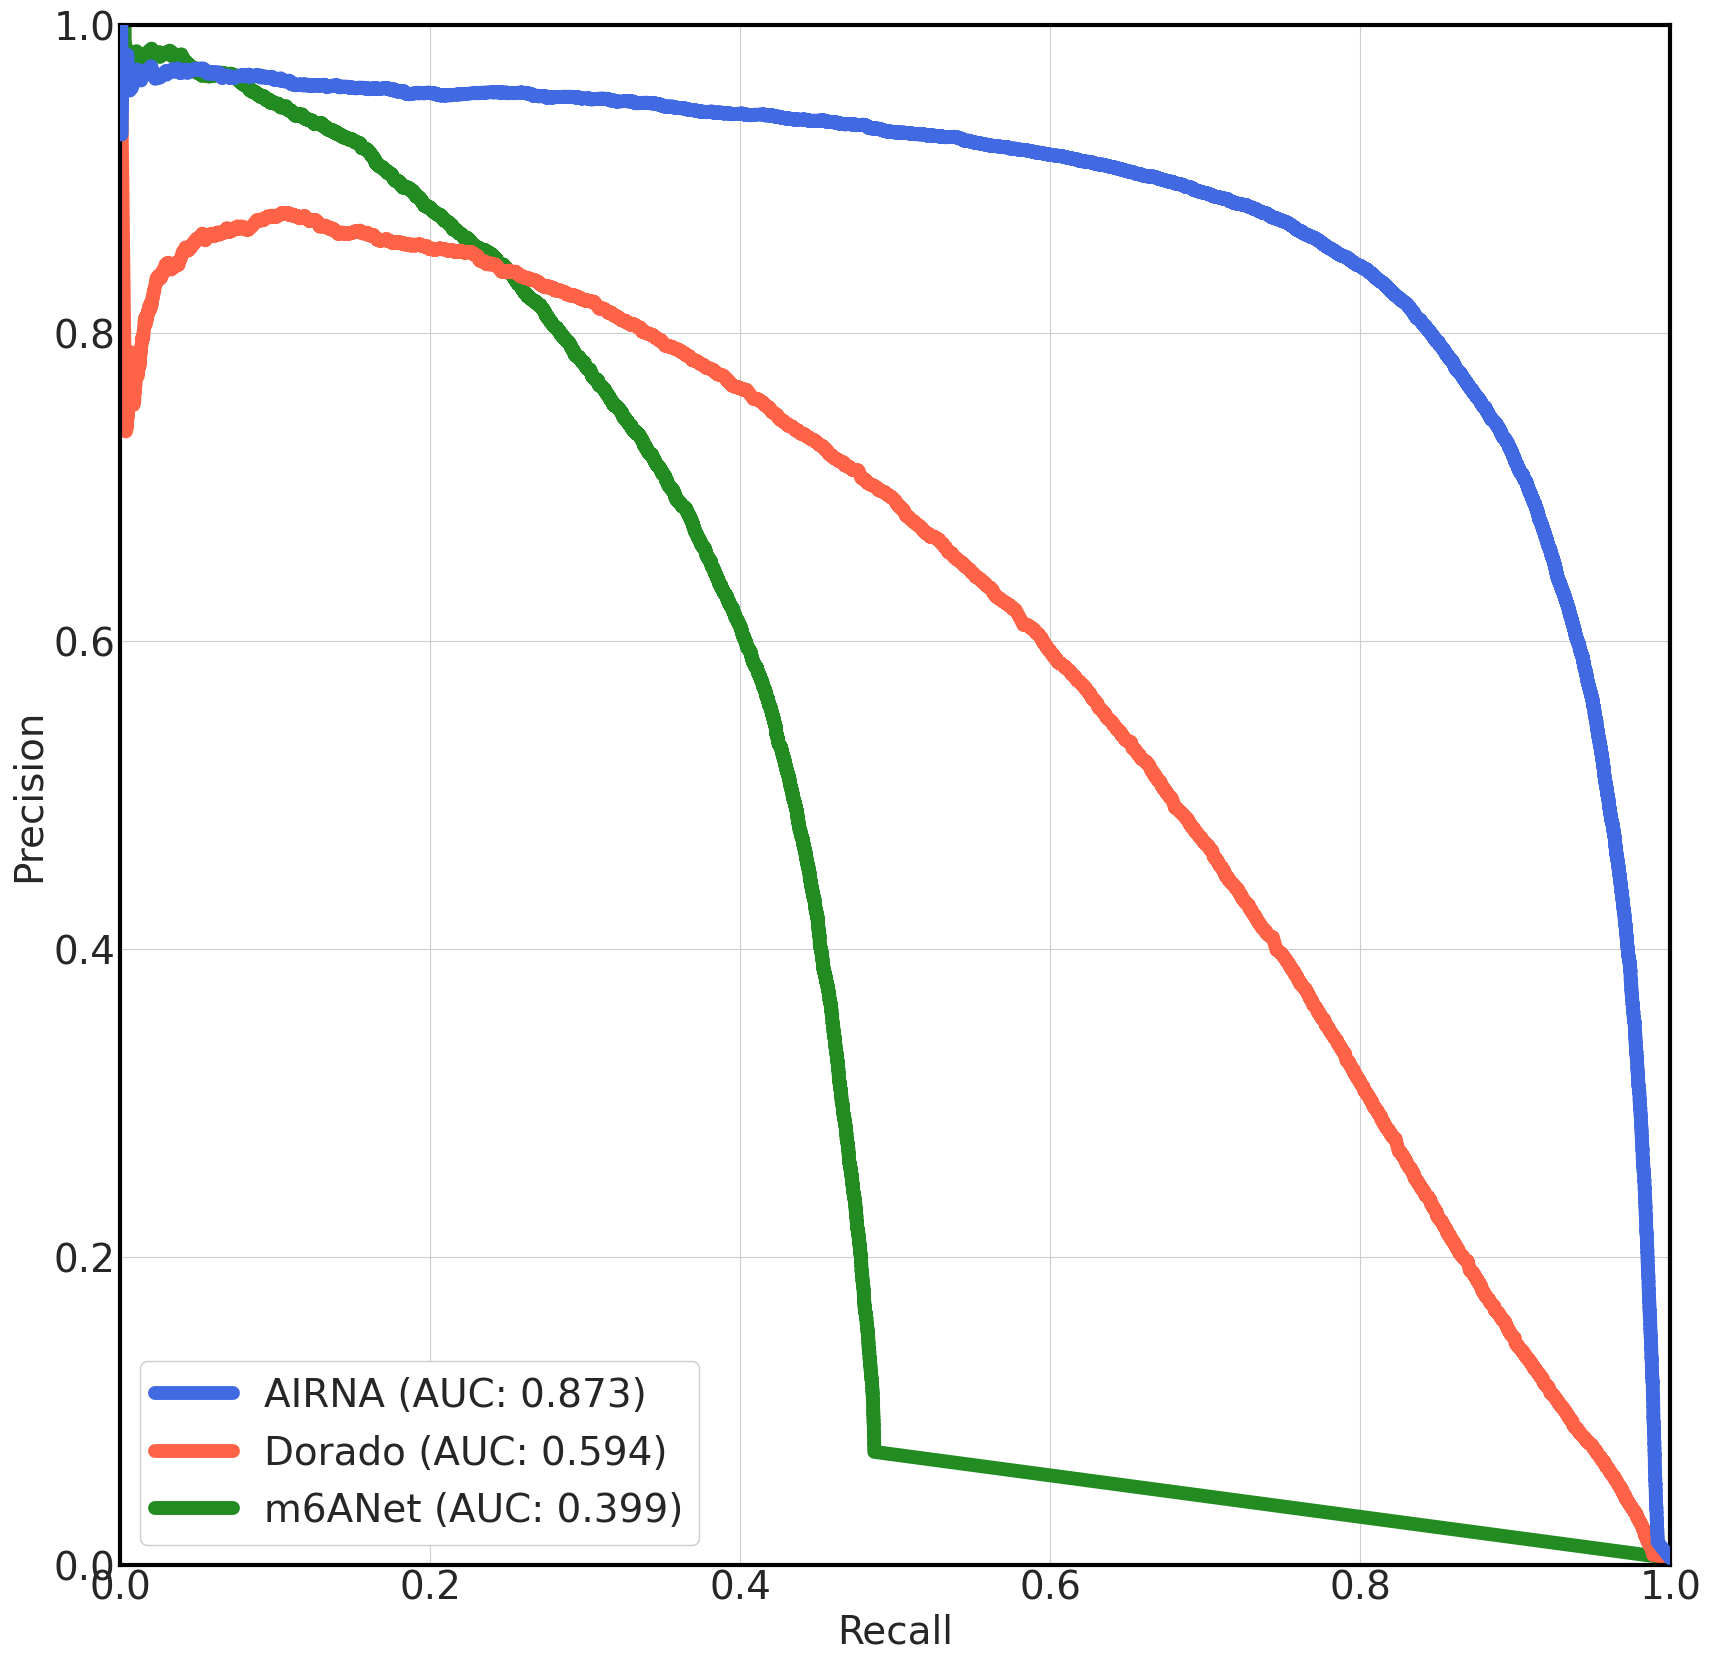

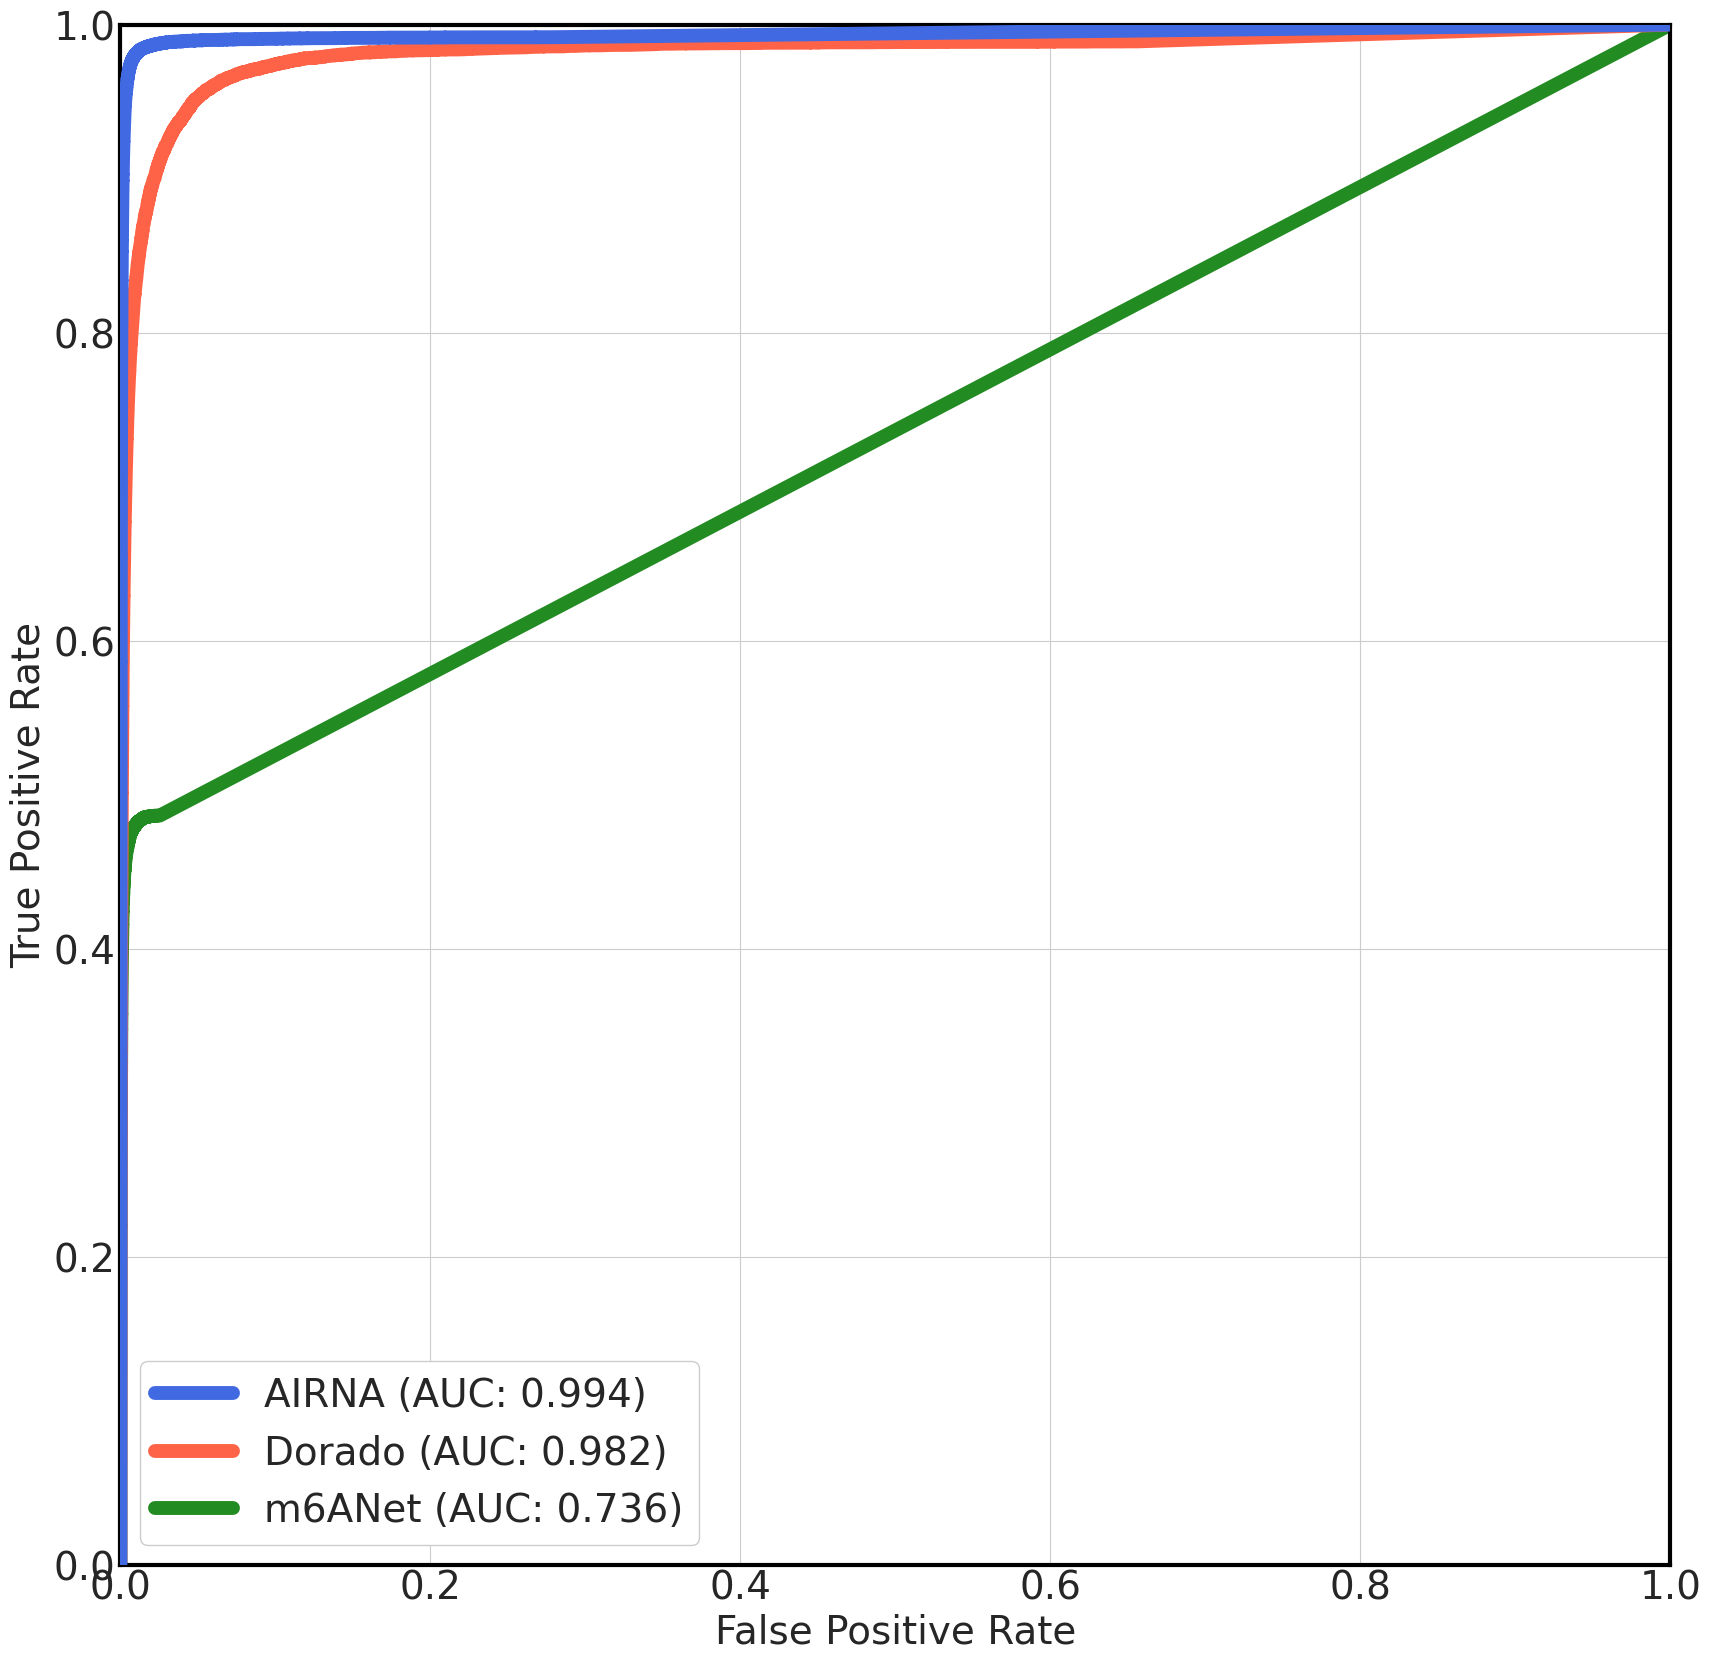

In [150]:
selected_df = final_benchmark_df.fillna(0).copy()
selected_df["pm6a"] = selected_df["pm6a"] * (selected_df["count_all"]>=20)
selected_df["pred_dorado"] = selected_df["pred_dorado"] * (selected_df["count_dorado"]>=20)
selected_df["pred_m6anet"] = selected_df["pred_m6anet"] * (selected_df["count_m6anet"]>=20)

## Plot PR
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_roc.pdf", format="pdf")
plt.show()


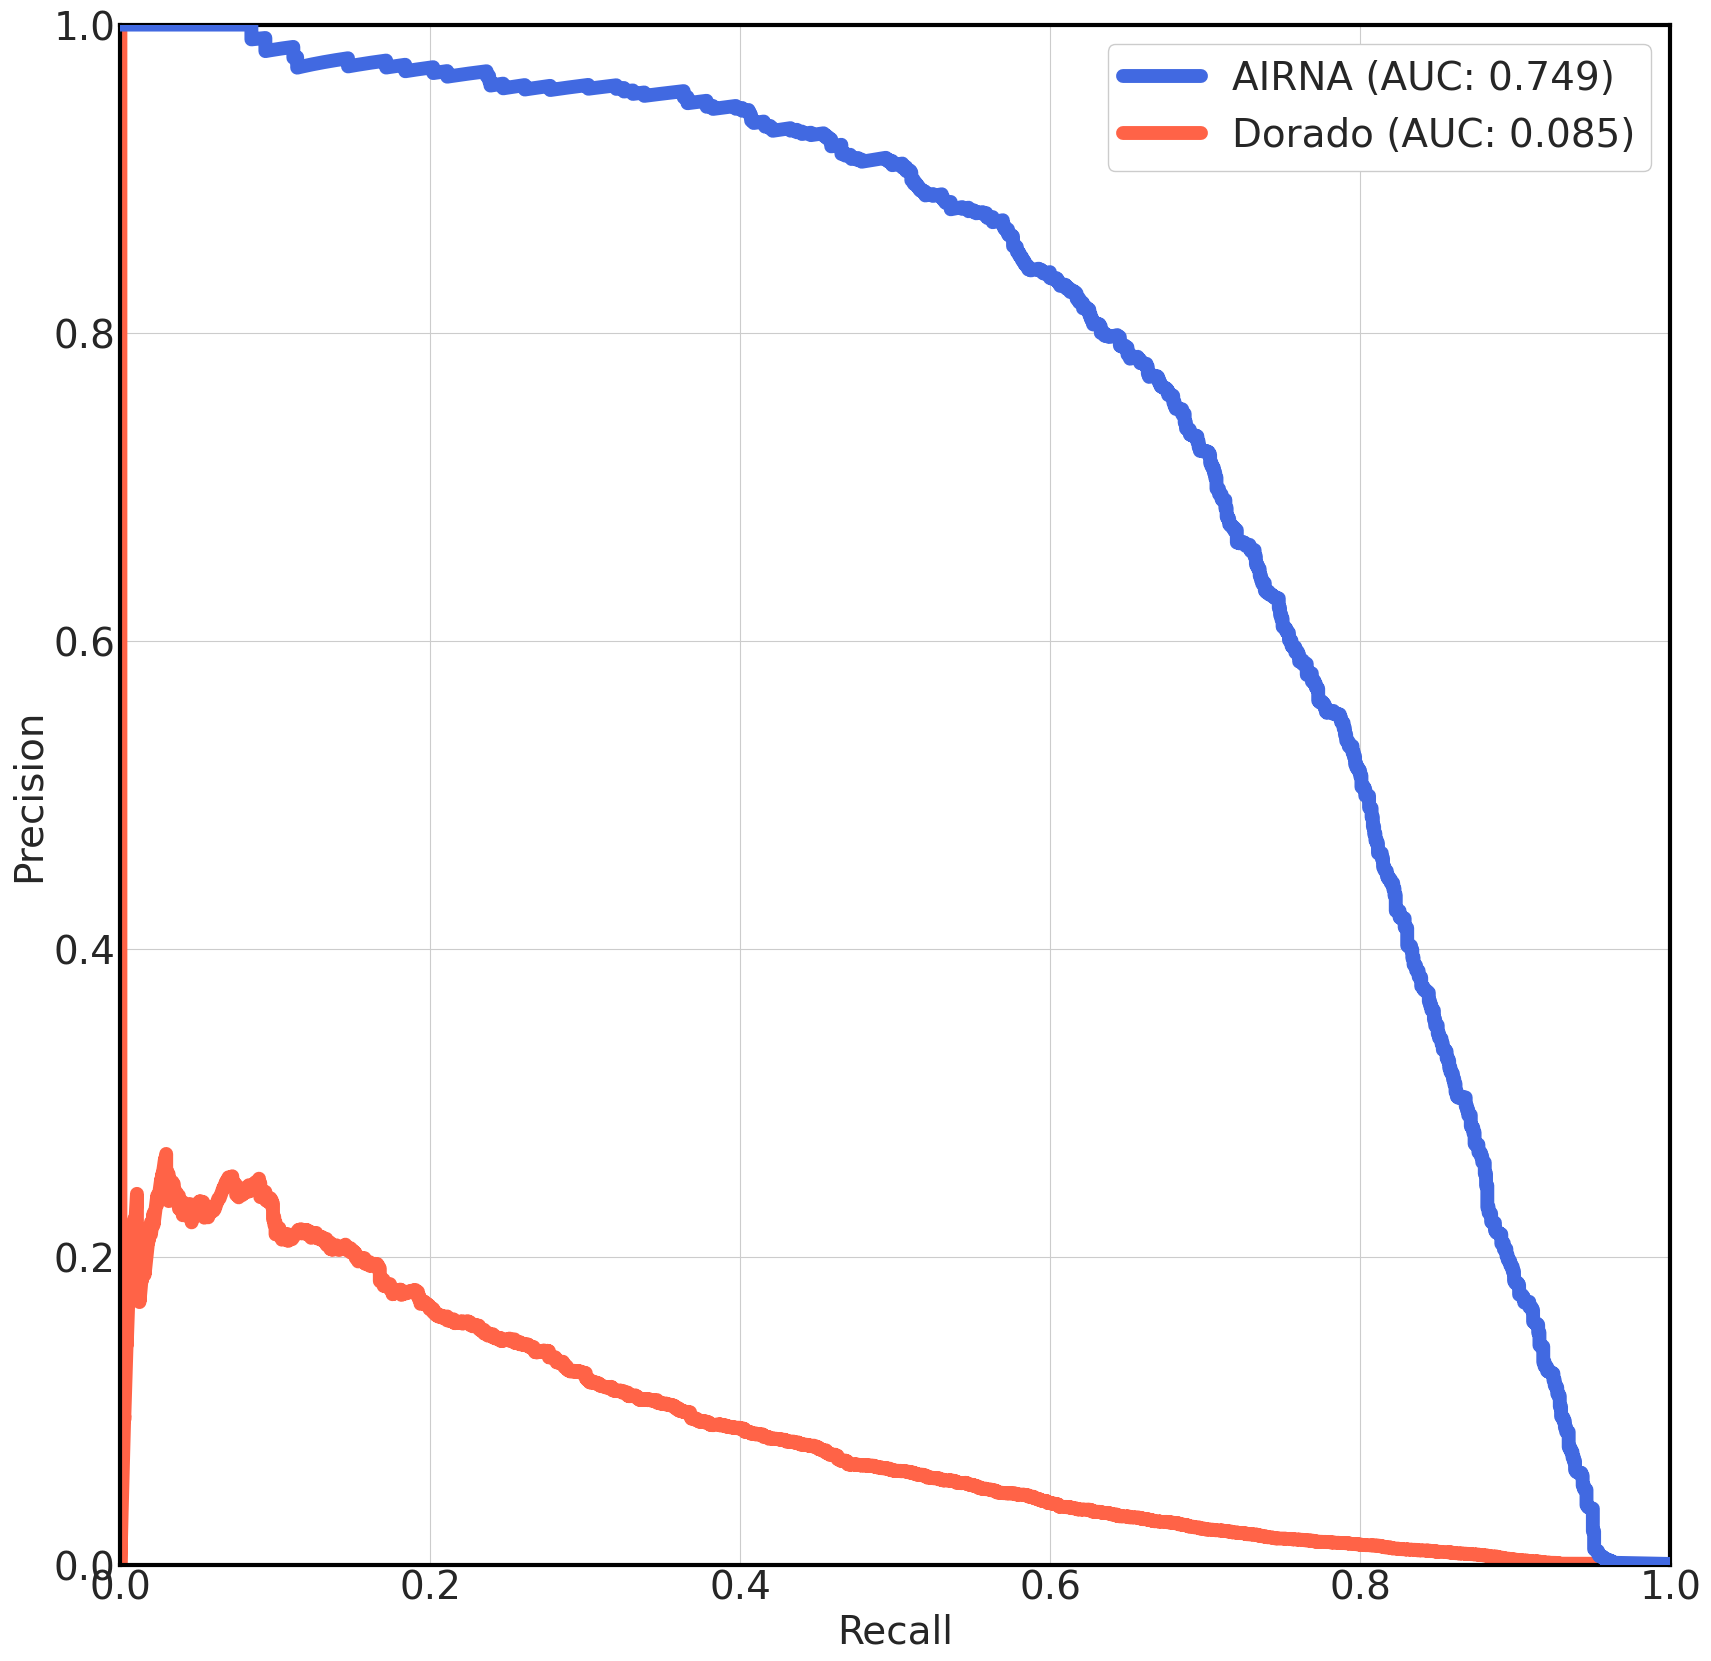

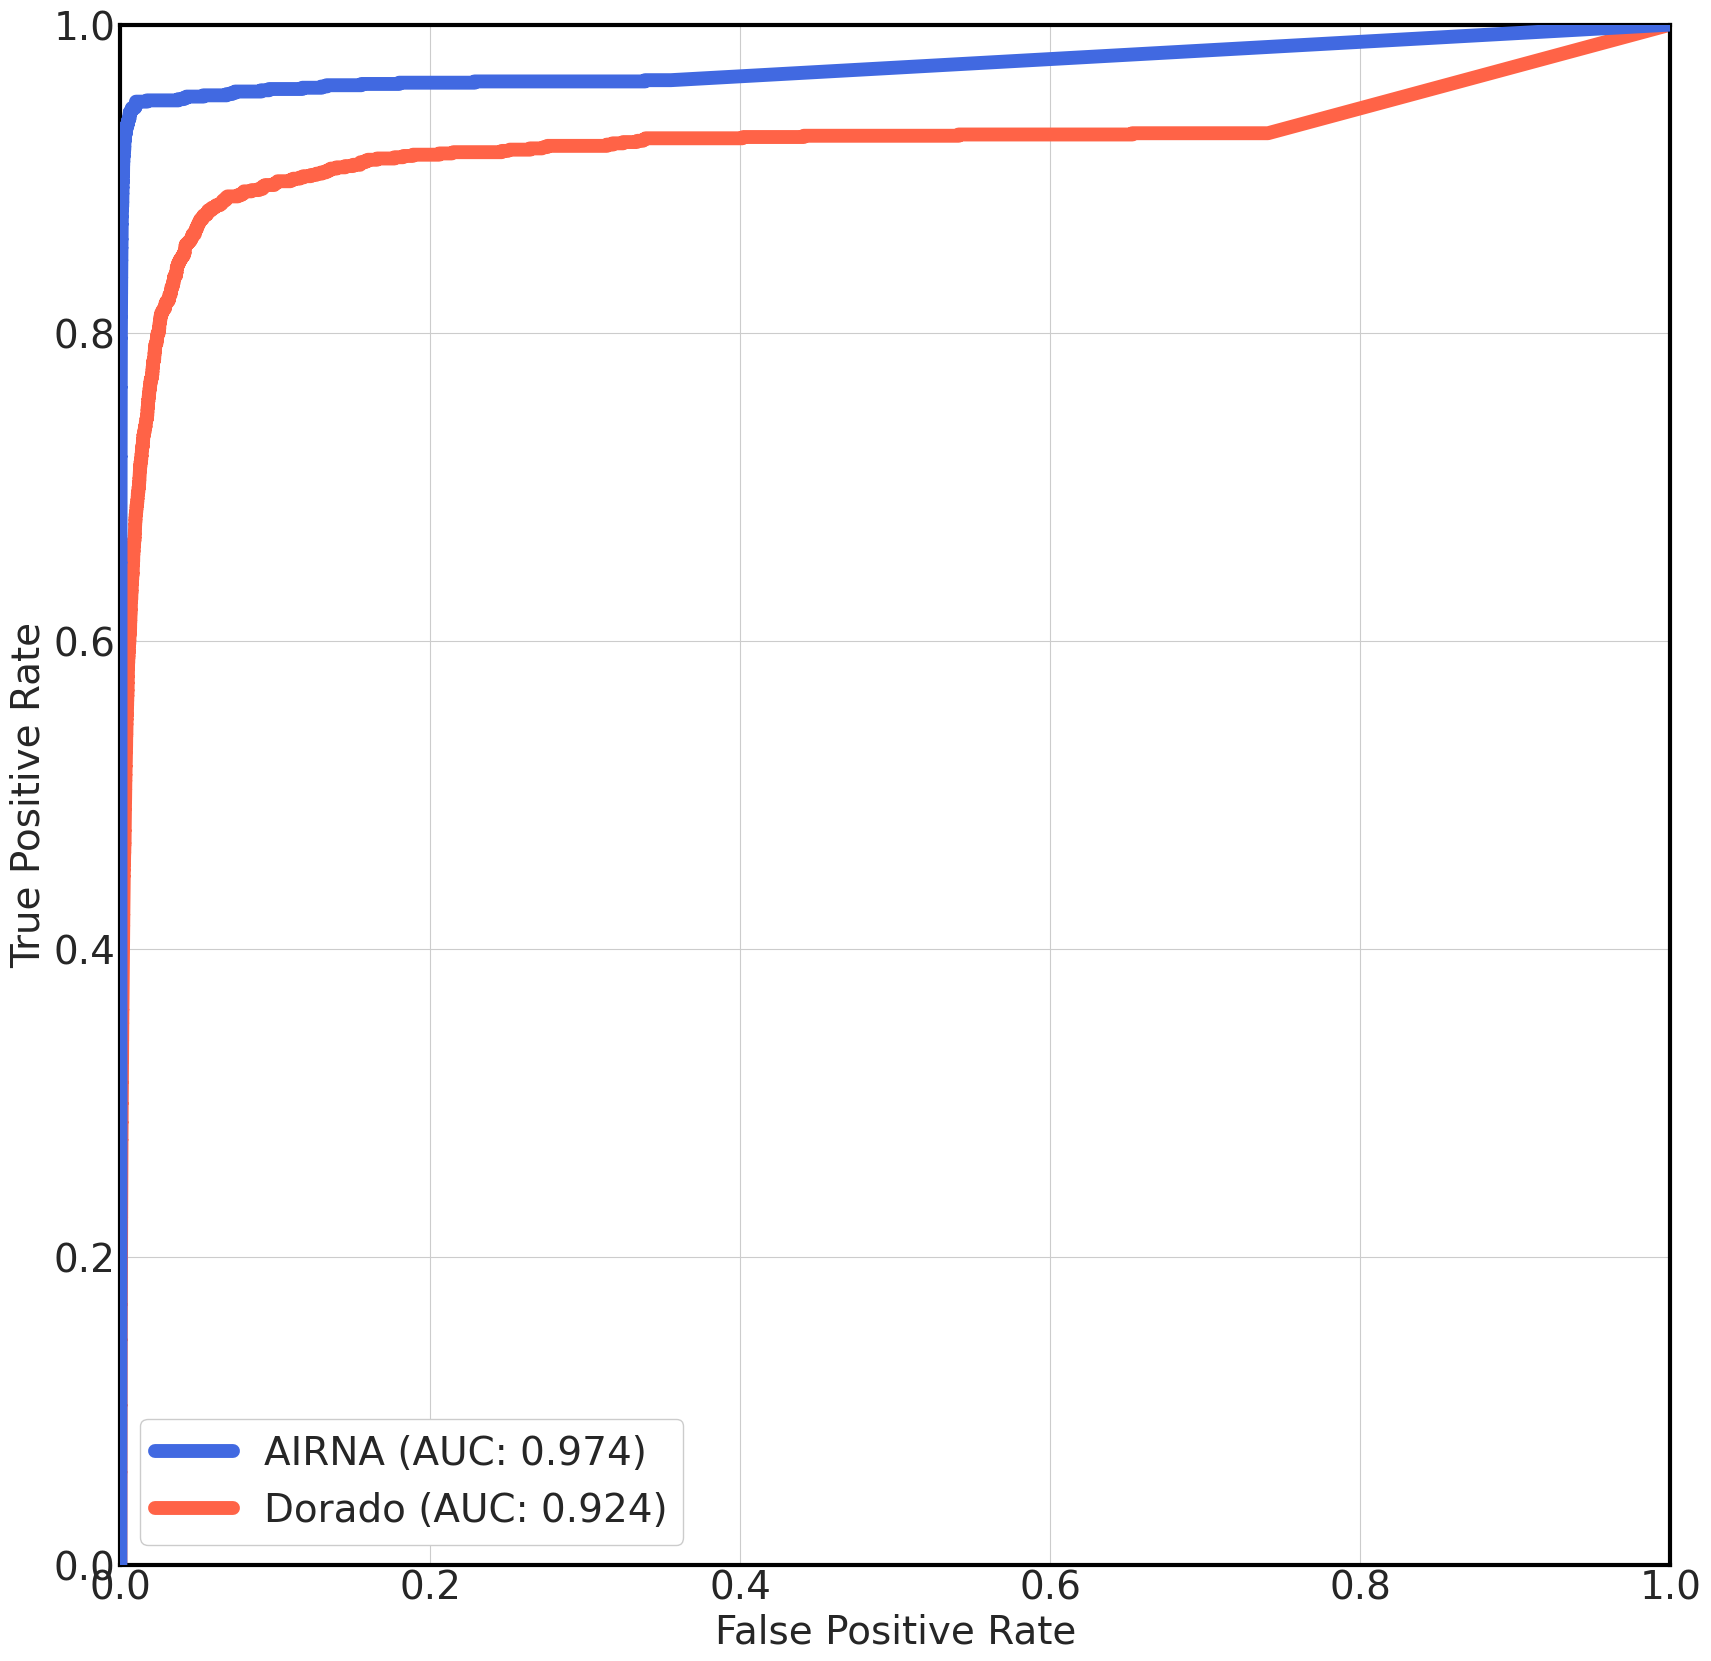

In [151]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = final_benchmark_df[~final_benchmark_df["drach"].fillna(0)].fillna(0)
selected_df = selected_df[selected_df["depth"] >= 100].copy()
selected_df["pm6a"] = selected_df["pm6a"] * (selected_df["count_all"]>=100)
selected_df["pred_dorado"] = selected_df["pred_dorado"] * (selected_df["count_dorado"]>=100)
selected_df["pred_m6anet"] = selected_df["pred_m6anet"] * (selected_df["count_m6anet"]>=100)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)


## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_roc.pdf", format="pdf")
plt.show()

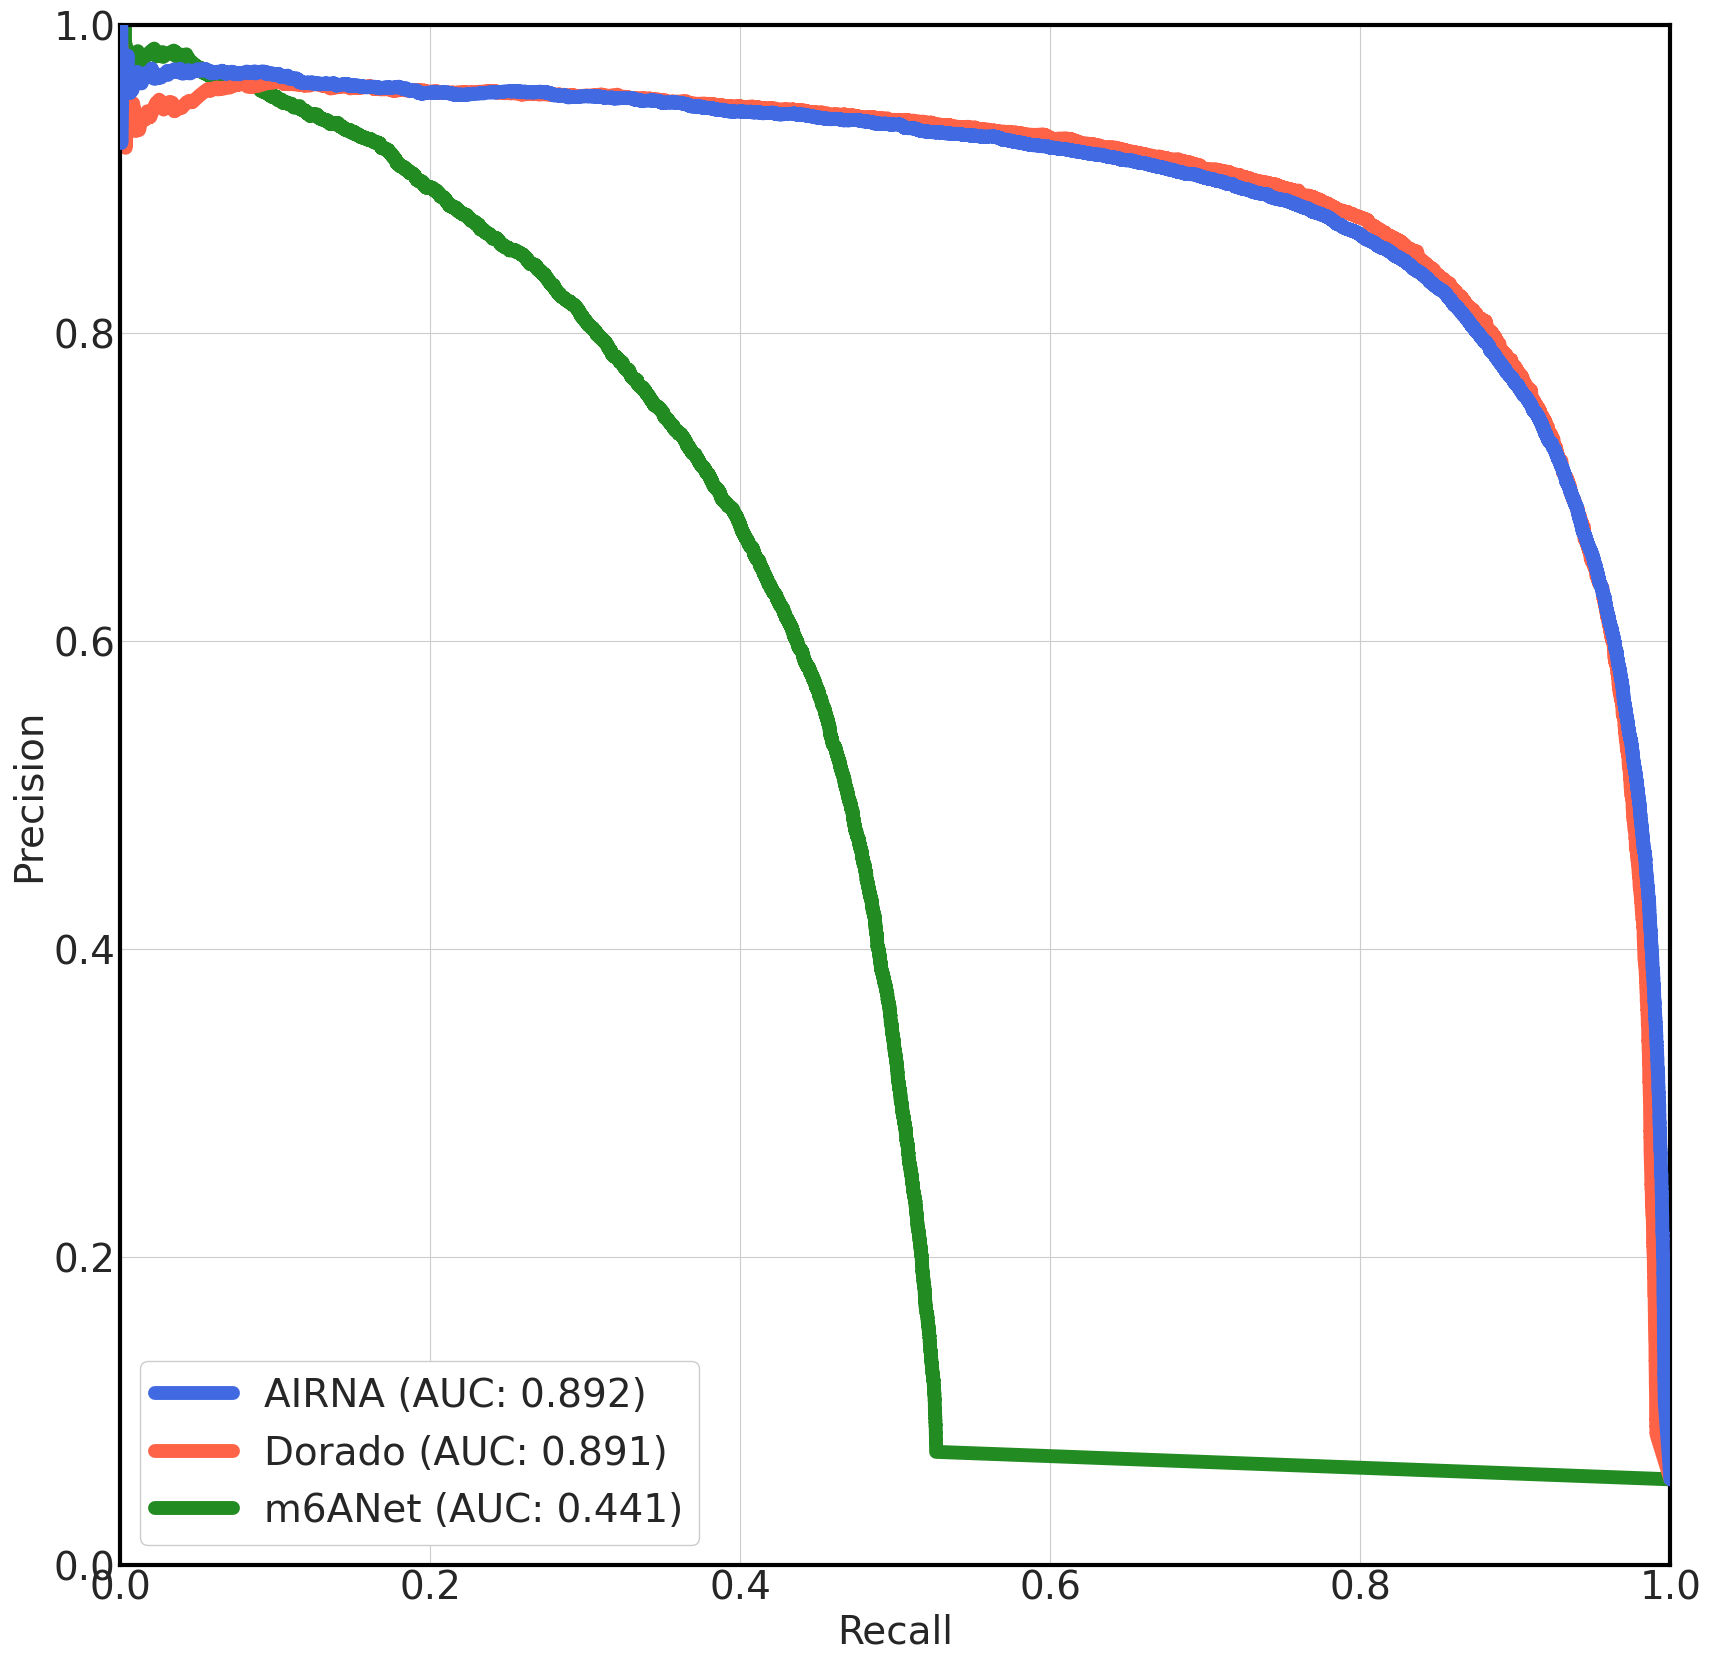

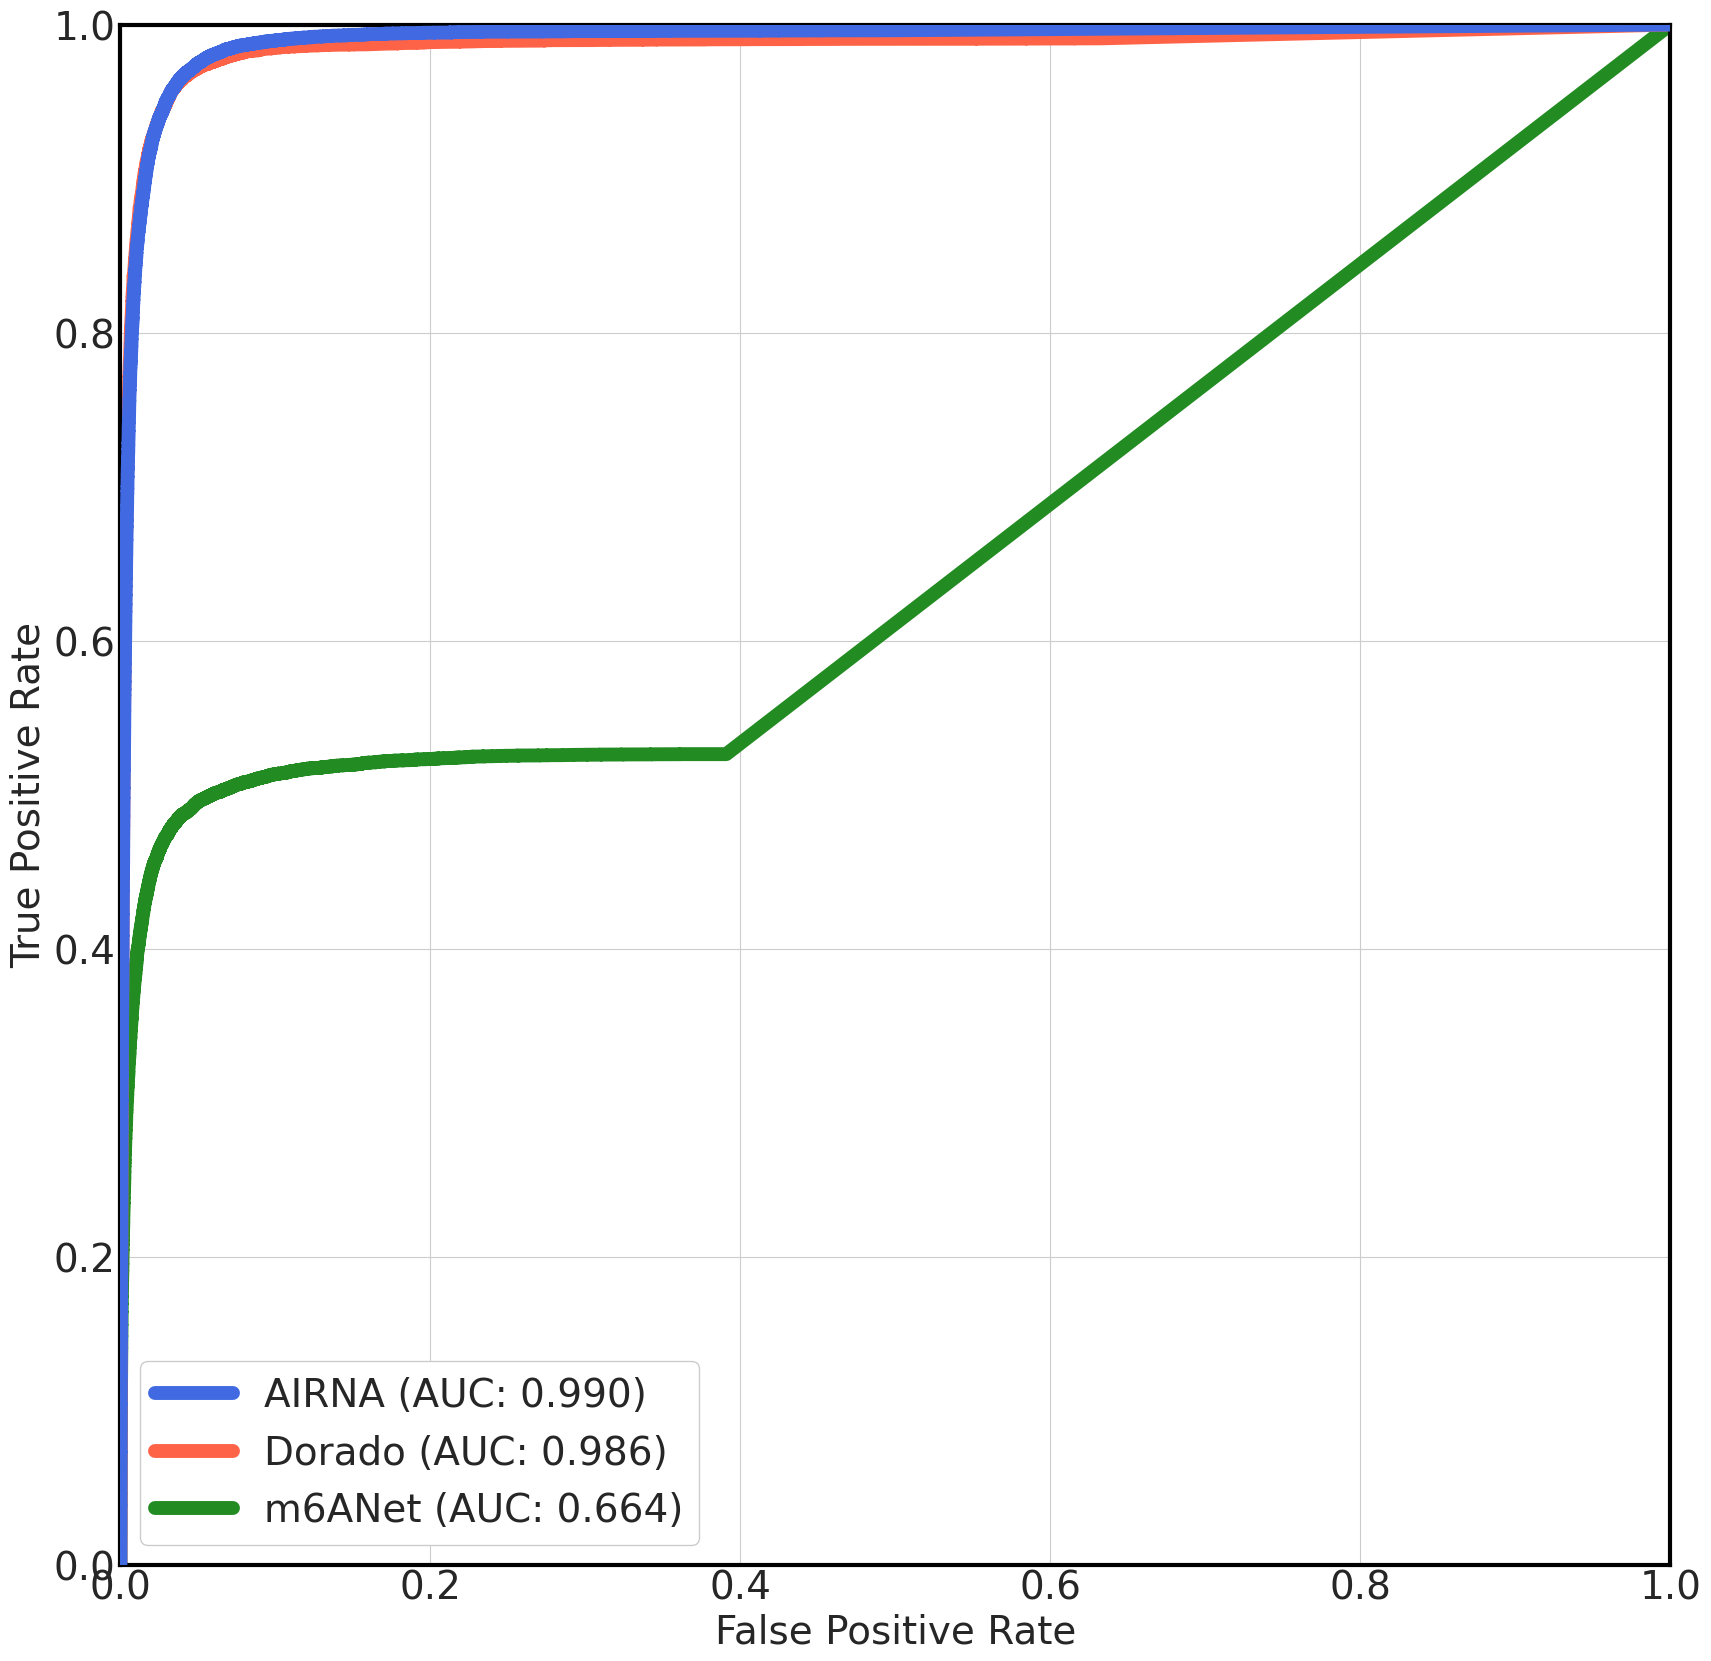

In [152]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = final_benchmark_df[final_benchmark_df["drach"].fillna(0)].fillna(0).copy()
selected_df["pm6a"] = selected_df["pm6a"] * (selected_df["count_all"]>=20)
selected_df["pred_dorado"] = selected_df["pred_dorado"] * (selected_df["count_dorado"]>=20)
selected_df["pred_m6anet"] = selected_df["pred_m6anet"] * (selected_df["count_m6anet"]>=20)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_roc.pdf", format="pdf")
plt.show()


In [153]:

selected_df = final_benchmark_df.fillna(0)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

/tmp/ipykernel_28379/3096591833.py:4: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * (precision * recall) / (precision + recall)


AIRNA Max F1: nan, Threshold: 3.946, Recall: 0.000, Precision: 0.000
Dorado Max F1: 0.575, Threshold: 0.501, Recall: 0.582, Precision: 0.569
m6Anet Max F1: 0.483, Threshold: 0.611, Recall: 0.400, Precision: 0.609
